# Bonus — Extension Questions

[`walkthrough/bonus.md`](../walkthrough/bonus.md)

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import kruskal, spearmanr
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

DATA_PATH = "../dataset/data.csv"
df = pd.read_csv(DATA_PATH)

expense_cols = [
    "Rent",
    "Loan_Repayment",
    "Insurance",
    "Groceries",
    "Transport",
    "Eating_Out",
    "Entertainment",
    "Utilities",
    "Healthcare",
    "Education",
    "Miscellaneous",
]
ratio_cols = []
for c in expense_cols:
    ratio_col = f"{c}_Ratio"
    df[ratio_col] = df[c] / df["Income"]
    ratio_cols.append(ratio_col)

df["Discretionary"] = df["Eating_Out"] + df["Entertainment"]
df["Discretionary_Ratio"] = df["Discretionary"] / df["Income"]
df["Disposable_Ratio"] = df["Disposable_Income"] / df["Income"]
df["Age_Band"] = pd.cut(
    df["Age"],
    [17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-64"],
)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Shape: {df.shape}")

Shape: (20000, 42)


In [2]:
def benchmark(X, y, tag, with_dummies=True):
    """5-fold CV of a categorical target against chance baselines. Returns the score table."""
    models = []
    if with_dummies:
        models += [
            ("Majority baseline", DummyClassifier(strategy="most_frequent")),
            ("Stratified baseline", DummyClassifier(strategy="stratified", random_state=42)),
        ]
    models += [
        ("Multinomial LogReg", make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))),
        ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ]

    rows = []
    for name, model in models:
        acc = cross_val_score(model, X, y, cv=CV, scoring="accuracy")
        f1 = cross_val_score(model, X, y, cv=CV, scoring="f1_macro")
        rows.append(
            {
                "Model": name,
                "CV Accuracy": acc.mean(),
                "Acc SD": acc.std(),
                "CV F1 (macro)": f1.mean(),
                "F1 SD": f1.std(),
            }
        )
    table = pd.DataFrame(rows).set_index("Model").round(4)
    print(f"--- {tag}  (X shape: {X.shape}) ---")
    print(table.to_string())
    return table

## BONUS-Q1 — Can `City_Tier` be predicted from spending mix alone?

In [3]:
X_q1 = df[ratio_cols]
y_q1 = df["City_Tier"]

q1_table = benchmark(X_q1, y_q1, "Q1: City_Tier ~ 11 expense-to-income ratios")

rf_q1 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
pred_q1 = cross_val_predict(rf_q1, X_q1, y_q1, cv=CV)

print("\nOut-of-fold confusion matrix (rows = true):")
print(
    pd.DataFrame(
        confusion_matrix(y_q1, pred_q1),
        index=sorted(y_q1.unique()),
        columns=sorted(y_q1.unique()),
    ).to_string()
)
print("\n" + classification_report(y_q1, pred_q1, digits=3))

rf_q1.fit(X_q1, y_q1)
imp_q1 = pd.Series(rf_q1.feature_importances_, index=ratio_cols).sort_values(ascending=False)
print("Random Forest feature importances:")
print(imp_q1.round(4).to_string())

--- Q1: City_Tier ~ 11 expense-to-income ratios  (X shape: (20000, 11)) ---
                     CV Accuracy  Acc SD  CV F1 (macro)   F1 SD
Model                                                          
Majority baseline         0.5034  0.0001         0.2232  0.0000
Stratified baseline       0.3828  0.0086         0.3338  0.0085
Multinomial LogReg        1.0000  0.0000         1.0000  0.0000
Random Forest             1.0000  0.0000         1.0000  0.0000



Out-of-fold confusion matrix (rows = true):
        Tier_1  Tier_2  Tier_3
Tier_1    5934       0       0
Tier_2       0   10068       0
Tier_3       0       0    3998



              precision    recall  f1-score   support

      Tier_1      1.000     1.000     1.000      5934
      Tier_2      1.000     1.000     1.000     10068
      Tier_3      1.000     1.000     1.000      3998

    accuracy                          1.000     20000
   macro avg      1.000     1.000     1.000     20000
weighted avg      1.000     1.000     1.000     20000



Random Forest feature importances:
Rent_Ratio              0.9738
Eating_Out_Ratio        0.0031
Miscellaneous_Ratio     0.0030
Entertainment_Ratio     0.0029
Insurance_Ratio         0.0028
Utilities_Ratio         0.0028
Healthcare_Ratio        0.0027
Groceries_Ratio         0.0027
Transport_Ratio         0.0026
Education_Ratio         0.0022
Loan_Repayment_Ratio    0.0014


### Q1 follow-up — where does the perfect score come from?

In [4]:
print("Mean expense ratio by city tier:")
print(df.groupby("City_Tier")[ratio_cols].mean().T.round(4).to_string())

print("\nRent_Ratio distribution within each tier:")
print(df.groupby("City_Tier")["Rent_Ratio"].describe().round(6).to_string())

print("\nDistinct Rent_Ratio values per tier (rounded to 6 dp):")
print(df.assign(RR=df["Rent_Ratio"].round(6)).groupby("City_Tier")["RR"].unique().to_string())

q1b_table = benchmark(
    df[["Rent_Ratio"]], y_q1, "Q1b: City_Tier ~ Rent_Ratio alone", with_dummies=False
)

X_q1c = df[[c for c in ratio_cols if c != "Rent_Ratio"]]
q1c_table = benchmark(
    X_q1c, y_q1, "Q1c: City_Tier ~ spending mix EXCLUDING Rent_Ratio", with_dummies=False
)

Mean expense ratio by city tier:
City_Tier             Tier_1  Tier_2  Tier_3
Rent_Ratio            0.3000  0.2000  0.1500
Loan_Repayment_Ratio  0.0501  0.0503  0.0485
Insurance_Ratio       0.0350  0.0350  0.0348
Groceries_Ratio       0.1253  0.1251  0.1255
Transport_Ratio       0.0650  0.0650  0.0651
Eating_Out_Ratio      0.0350  0.0352  0.0350
Entertainment_Ratio   0.0348  0.0350  0.0347
Utilities_Ratio       0.0600  0.0603  0.0601
Healthcare_Ratio      0.0400  0.0400  0.0398
Education_Ratio       0.0603  0.0597  0.0601
Miscellaneous_Ratio   0.0201  0.0200  0.0201

Rent_Ratio distribution within each tier:
             count  mean  std   min   25%   50%   75%   max
City_Tier                                                  
Tier_1      5934.0  0.30  0.0  0.30  0.30  0.30  0.30  0.30
Tier_2     10068.0  0.20  0.0  0.20  0.20  0.20  0.20  0.20
Tier_3      3998.0  0.15  0.0  0.15  0.15  0.15  0.15  0.15

Distinct Rent_Ratio values per tier (rounded to 6 dp):
City_Tier
Tier_1     [0.3]
T

--- Q1b: City_Tier ~ Rent_Ratio alone  (X shape: (20000, 1)) ---
                    CV Accuracy  Acc SD  CV F1 (macro)  F1 SD
Model                                                        
Multinomial LogReg          1.0     0.0            1.0    0.0
Random Forest               1.0     0.0            1.0    0.0


--- Q1c: City_Tier ~ spending mix EXCLUDING Rent_Ratio  (X shape: (20000, 10)) ---
                    CV Accuracy  Acc SD  CV F1 (macro)  F1 SD
Model                                                        
Multinomial LogReg       0.5034  0.0001         0.2232  0.000
Random Forest            0.4925  0.0038         0.2511  0.003


## BONUS-Q2 — Can `Occupation` be predicted from income + expense pattern?

In [5]:
X_q2 = df[["Income"] + ratio_cols]
y_q2 = df["Occupation"]

q2_table = benchmark(X_q2, y_q2, "Q2: Occupation ~ Income + 11 expense ratios")

rf_q2 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
pred_q2 = cross_val_predict(rf_q2, X_q2, y_q2, cv=CV)

print("\nOut-of-fold confusion matrix (rows = true):")
print(
    pd.DataFrame(
        confusion_matrix(y_q2, pred_q2),
        index=sorted(y_q2.unique()),
        columns=sorted(y_q2.unique()),
    ).to_string()
)
print("\n" + classification_report(y_q2, pred_q2, digits=3))

rf_q2.fit(X_q2, y_q2)
imp_q2 = pd.Series(rf_q2.feature_importances_, index=X_q2.columns).sort_values(ascending=False)
print("Random Forest feature importances (near-uniform => no feature carries signal):")
print(imp_q2.round(4).to_string())

--- Q2: Occupation ~ Income + 11 expense ratios  (X shape: (20000, 12)) ---
                     CV Accuracy  Acc SD  CV F1 (macro)   F1 SD
Model                                                          
Majority baseline         0.2510  0.0001         0.1003  0.0000
Stratified baseline       0.2496  0.0029         0.2494  0.0030
Multinomial LogReg        0.2496  0.0075         0.2434  0.0068
Random Forest             0.2590  0.0061         0.2585  0.0061



Out-of-fold confusion matrix (rows = true):
               Professional  Retired  Self_Employed  Student
Professional           1403     1279           1148     1181
Retired                1286     1399           1168     1166
Self_Employed          1298     1307           1156     1206
Student                1303     1313           1165     1222

               precision    recall  f1-score   support

 Professional      0.265     0.280     0.272      5011
      Retired      0.264     0.279     0.271      5019
Self_Employed      0.249     0.233     0.241      4967
      Student      0.256     0.244     0.250      5003

     accuracy                          0.259     20000
    macro avg      0.259     0.259     0.259     20000
 weighted avg      0.259     0.259     0.259     20000



Random Forest feature importances (near-uniform => no feature carries signal):
Miscellaneous_Ratio     0.0947
Utilities_Ratio         0.0946
Entertainment_Ratio     0.0945
Groceries_Ratio         0.0942
Income                  0.0941
Eating_Out_Ratio        0.0939
Transport_Ratio         0.0938
Healthcare_Ratio        0.0937
Insurance_Ratio         0.0935
Education_Ratio         0.0806
Loan_Repayment_Ratio    0.0458
Rent_Ratio              0.0267


### Q2 follow-up — is the signal hiding in a demographic the question excluded?

In [6]:
q2b_table = benchmark(
    df[["Income", "Age", "Dependents"] + ratio_cols],
    y_q2,
    "Q2b: Occupation ~ Income + Age + Dependents + expense ratios (diagnostic)",
    with_dummies=False,
)

print("\nAge and Income by occupation:")
print(
    df.groupby("Occupation")[["Age", "Income"]]
    .agg(["mean", "std", "min", "max"])
    .round(2)
    .to_string()
)

--- Q2b: Occupation ~ Income + Age + Dependents + expense ratios (diagnostic)  (X shape: (20000, 14)) ---
                    CV Accuracy  Acc SD  CV F1 (macro)   F1 SD
Model                                                         
Multinomial LogReg       0.2512  0.0055         0.2452  0.0066
Random Forest            0.2555  0.0078         0.2552  0.0079

Age and Income by occupation:
                 Age                   Income                               
                mean    std min max      mean       std      min         max
Occupation                                                                  
Professional   41.16  13.48  18  64  42020.47  42891.89  2227.61  1079728.37
Retired        41.26  13.63  18  64  40666.77  37969.71  1301.19   702792.86
Self_Employed  40.83  13.48  18  64  41829.16  40064.60  1393.58   693802.64
Student        40.88  13.72  18  64  41829.58  38961.92  1682.58   385940.59


## BONUS-Q3 — Does a lifecycle pattern exist between age and discretionary spending?

In [7]:
disc_cols = ["Discretionary", "Discretionary_Ratio", "Eating_Out_Ratio", "Entertainment_Ratio"]

print("Discretionary spending by age band:")
print(df.groupby("Age_Band")[disc_cols + ["Income"]].agg(["mean", "count"]).round(4).to_string())

print("\nMonotonic-trend and between-band tests:")
for col in disc_cols:
    rho, p = spearmanr(df["Age"], df[col])
    h, ph = kruskal(*[g[col].values for _, g in df.groupby("Age_Band")])
    print(f"  {col:22s} Spearman rho={rho:+.4f} (p={p:.3f})   Kruskal-Wallis H={h:.2f} (p={ph:.3f})")

Discretionary spending by age band:
         Discretionary       Discretionary_Ratio       Eating_Out_Ratio       Entertainment_Ratio            Income      
                  mean count                mean count             mean count                mean count        mean count
Age_Band                                                                                                                 
18-25        2932.3763  3454              0.0702  3454           0.0352  3454              0.0350  3454  42133.0673  3454
26-35        2919.0230  4148              0.0701  4148           0.0351  4148              0.0350  4148  41458.5768  4148
36-45        2872.8385  4295              0.0698  4295           0.0350  4295              0.0348  4295  41096.5696  4295
46-55        2952.6300  4224              0.0699  4224           0.0351  4224              0.0348  4224  42191.9615  4224
56-64        2878.8159  3879              0.0700  3879           0.0350  3879              0.0350  3879  41114

In [8]:
m_lin = smf.ols("Discretionary_Ratio ~ Age", data=df).fit()
m_quad = smf.ols("Discretionary_Ratio ~ Age + I(Age**2)", data=df).fit()
m_ctrl = smf.ols(
    "Discretionary_Ratio ~ Age + I(Age**2) + np.log(Income) + Dependents"
    " + C(City_Tier) + C(Occupation)",
    data=df,
).fit()

for name, model in [("linear", m_lin), ("quadratic", m_quad), ("quadratic + controls", m_ctrl)]:
    print(f"\n[{name}]  R2 = {model.rsquared:.6f}   adj. R2 = {model.rsquared_adj:.6f}")
    print(model.summary2().tables[1].round(6).to_string())

print("\nNested F-test — does the Age^2 (inverted-U lifecycle) term add anything?")
print(sm.stats.anova_lm(m_lin, m_quad).round(6).to_string())


[linear]  R2 = 0.000015   adj. R2 = -0.000035
              Coef.  Std.Err.           t     P>|t|    [0.025    0.975]
Intercept  0.070126  0.000277  253.528821  0.000000  0.069583  0.070668
Age       -0.000004  0.000006   -0.547853  0.583799 -0.000016  0.000009

[quadratic]  R2 = 0.000037   adj. R2 = -0.000063
                Coef.  Std.Err.          t     P>|t|    [0.025    0.975]
Intercept    0.070652  0.000834  84.714946  0.000000  0.069018  0.072287
Age         -0.000032  0.000044  -0.742566  0.457753 -0.000118  0.000053
I(Age ** 2)  0.000000  0.000001   0.669428  0.503230 -0.000001  0.000001

[quadratic + controls]  R2 = 0.000392   adj. R2 = -0.000058
                                   Coef.  Std.Err.          t     P>|t|    [0.025    0.975]
Intercept                       0.070234  0.001409  49.849147  0.000000  0.067472  0.072996
C(City_Tier)[T.Tier_2]          0.000326  0.000201   1.622457  0.104721 -0.000068  0.000721
C(City_Tier)[T.Tier_3]         -0.000100  0.000251  -0.396

## BONUS-Q4 — Does `City_Tier` still affect disposable income after controlling for income level?

In [9]:
print("Raw means by tier:")
print(
    df.groupby("City_Tier")[["Income", "Disposable_Income", "Disposable_Ratio", "Rent_Ratio"]]
    .agg(["mean", "count"])
    .round(4)
    .to_string()
)

m_inc = smf.ols("Disposable_Income ~ Income", data=df).fit()
m_tier = smf.ols("Disposable_Income ~ Income + C(City_Tier)", data=df).fit()
m_demo = smf.ols(
    "Disposable_Income ~ Income + C(City_Tier) + Dependents + Age + C(Occupation)", data=df
).fit()
m_intx = smf.ols("Disposable_Income ~ Income * C(City_Tier)", data=df).fit()

for name, model in [
    ("income only", m_inc),
    ("+ city tier", m_tier),
    ("+ tier + demographics", m_demo),
    ("income x tier interaction", m_intx),
]:
    print(f"\n[{name}]  R2 = {model.rsquared:.6f}   adj. R2 = {model.rsquared_adj:.6f}")
    print(model.summary2().tables[1].round(4).to_string())

print("\nNested F-test — does tier add explanatory power over income alone?")
print(sm.stats.anova_lm(m_inc, m_tier).round(6).to_string())

Raw means by tier:
               Income        Disposable_Income        Disposable_Ratio        Rent_Ratio       
                 mean  count              mean  count             mean  count       mean  count
City_Tier                                                                                      
Tier_1     41068.3901   5934         7155.8968   5934           0.1743   5934       0.30   5934
Tier_2     41713.2107  10068        11485.9654  10068           0.2745  10068       0.20  10068
Tier_3     42031.3882   3998        13717.7474   3998           0.3262   3998       0.15   3998



[income only]  R2 = 0.777074   adj. R2 = 0.777063
              Coef.  Std.Err.         t   P>|t|    [0.025  0.975]
Intercept -108.5394   56.5342   -1.9199  0.0549 -219.3511  2.2723
Income       0.2586    0.0010  264.0247  0.0000    0.2567  0.2606

[+ city tier]  R2 = 0.816381   adj. R2 = 0.816353
                            Coef.  Std.Err.         t  P>|t|     [0.025     0.975]
Intercept              -3444.9623   74.8293  -46.0376    0.0 -3591.6339 -3298.2906
C(City_Tier)[T.Tier_2]  4163.6230   82.3448   50.5633    0.0  4002.2205  4325.0255
C(City_Tier)[T.Tier_3]  6313.2748  102.9489   61.3243    0.0  6111.4864  6515.0632
Income                     0.2581    0.0009  290.3050    0.0     0.2564     0.2599

[+ tier + demographics]  R2 = 0.821733   adj. R2 = 0.821662
                                    Coef.  Std.Err.         t   P>|t|     [0.025     0.975]
Intercept                      -2248.2783  151.6805  -14.8225  0.0000 -2545.5846 -1950.9720
C(City_Tier)[T.Tier_2]          4147.539

In [10]:
m_scalefree = smf.ols("Disposable_Ratio ~ np.log(Income) + C(City_Tier)", data=df).fit()
print(f"[share of income kept]  R2 = {m_scalefree.rsquared:.6f}")
print(m_scalefree.summary2().tables[1].round(6).to_string())

tier_means = df.groupby("City_Tier")[ratio_cols].mean()
gap = (tier_means.loc["Tier_1"] - tier_means.loc["Tier_3"]).sort_values(ascending=False)
print("\nMechanism — Tier_1 minus Tier_3 mean expense ratio, by category:")
print(gap.round(5).to_string())
print(f"\nRent_Ratio share of the total Tier_1 - Tier_3 gap: {gap['Rent_Ratio'] / gap.sum():.1%}")

identity_err = (
    (df["Disposable_Income"] - (df["Income"] - df[expense_cols].sum(axis=1))).abs().max()
)
print(
    f"\nAccounting identity check (Disposable = Income - sum(expenses)): max error = {identity_err:.2e}"
)

[share of income kept]  R2 = 0.332457
                           Coef.  Std.Err.          t    P>|t|    [0.025    0.975]
Intercept               0.165275  0.007290  22.672715  0.00000  0.150986  0.179563
C(City_Tier)[T.Tier_2]  0.100244  0.001300  77.127469  0.00000  0.097696  0.102791
C(City_Tier)[T.Tier_3]  0.151943  0.001625  93.510007  0.00000  0.148758  0.155128
np.log(Income)          0.000874  0.000700   1.247442  0.21225 -0.000499  0.002247

Mechanism — Tier_1 minus Tier_3 mean expense ratio, by category:
Rent_Ratio              0.15000
Loan_Repayment_Ratio    0.00162
Insurance_Ratio         0.00024
Education_Ratio         0.00017
Healthcare_Ratio        0.00016
Entertainment_Ratio     0.00012
Eating_Out_Ratio       -0.00002
Miscellaneous_Ratio    -0.00003
Transport_Ratio        -0.00006
Groceries_Ratio        -0.00011
Utilities_Ratio        -0.00013

Rent_Ratio share of the total Tier_1 - Tier_3 gap: 98.7%

Accounting identity check (Disposable = Income - sum(expenses)): max e

## Summary table and figure

In [11]:
summary = pd.DataFrame(
    [
        {
            "id": "BONUS-Q1",
            "question": "Can City_Tier be predicted from spending mix alone?",
            "answer": "Yes - perfectly, but trivially",
            "key_evidence": (
                f"CV accuracy {q1_table.loc['Random Forest', 'CV Accuracy']:.4f} vs "
                f"{q1_table.loc['Majority baseline', 'CV Accuracy']:.4f} majority baseline; "
                f"Rent_Ratio is a deterministic tier lookup (0.30/0.20/0.15) and alone scores "
                f"{q1b_table.loc['Random Forest', 'CV Accuracy']:.4f}; the other 10 ratios score "
                f"{q1c_table.loc['Random Forest', 'CV Accuracy']:.4f}"
            ),
        },
        {
            "id": "BONUS-Q2",
            "question": "Can Occupation be predicted from income + expense pattern?",
            "answer": "No - indistinguishable from chance",
            "key_evidence": (
                f"CV accuracy {q2_table.loc['Random Forest', 'CV Accuracy']:.4f} vs "
                f"{q2_table.loc['Majority baseline', 'CV Accuracy']:.4f} majority baseline "
                f"(4 balanced classes); adding Age and Dependents gives "
                f"{q2b_table.loc['Random Forest', 'CV Accuracy']:.4f}"
            ),
        },
        {
            "id": "BONUS-Q3",
            "question": "Does a lifecycle pattern exist between age and discretionary spending?",
            "answer": "No - discretionary share is flat across age",
            "key_evidence": (
                f"Discretionary_Ratio ~ Age R2 = {m_lin.rsquared:.6f}; Age^2 term p = "
                f"{m_quad.pvalues['I(Age ** 2)']:.3f}; Spearman rho = "
                f"{spearmanr(df['Age'], df['Discretionary_Ratio'])[0]:+.4f}"
            ),
        },
        {
            "id": "BONUS-Q4",
            "question": "Does City_Tier affect disposable income after controlling for income?",
            "answer": "Yes - strongly, entirely via rent",
            "key_evidence": (
                f"R2 rises {m_inc.rsquared:.3f} -> {m_tier.rsquared:.3f} when tier is added "
                f"(F = {sm.stats.anova_lm(m_inc, m_tier)['F'].iloc[1]:.0f}); Tier_3 keeps "
                f"{m_scalefree.params['C(City_Tier)[T.Tier_3]']:.3f} more of each rupee than Tier_1; "
                f"Rent_Ratio accounts for {gap['Rent_Ratio'] / gap.sum():.1%} of the "
                f"Tier_1-Tier_3 expense gap"
            ),
        },
    ]
)
summary.to_csv("../results/bonus_extension_summary.csv", index=False)
print(summary.to_string(index=False))

      id                                                               question                                      answer                                                                                                                                                             key_evidence
BONUS-Q1                    Can City_Tier be predicted from spending mix alone?              Yes - perfectly, but trivially     CV accuracy 1.0000 vs 0.5034 majority baseline; Rent_Ratio is a deterministic tier lookup (0.30/0.20/0.15) and alone scores 1.0000; the other 10 ratios score 0.4925
BONUS-Q2             Can Occupation be predicted from income + expense pattern?          No - indistinguishable from chance                                                              CV accuracy 0.2590 vs 0.2510 majority baseline (4 balanced classes); adding Age and Dependents gives 0.2555
BONUS-Q3 Does a lifecycle pattern exist between age and discretionary spending? No - discretionary share is flat across a

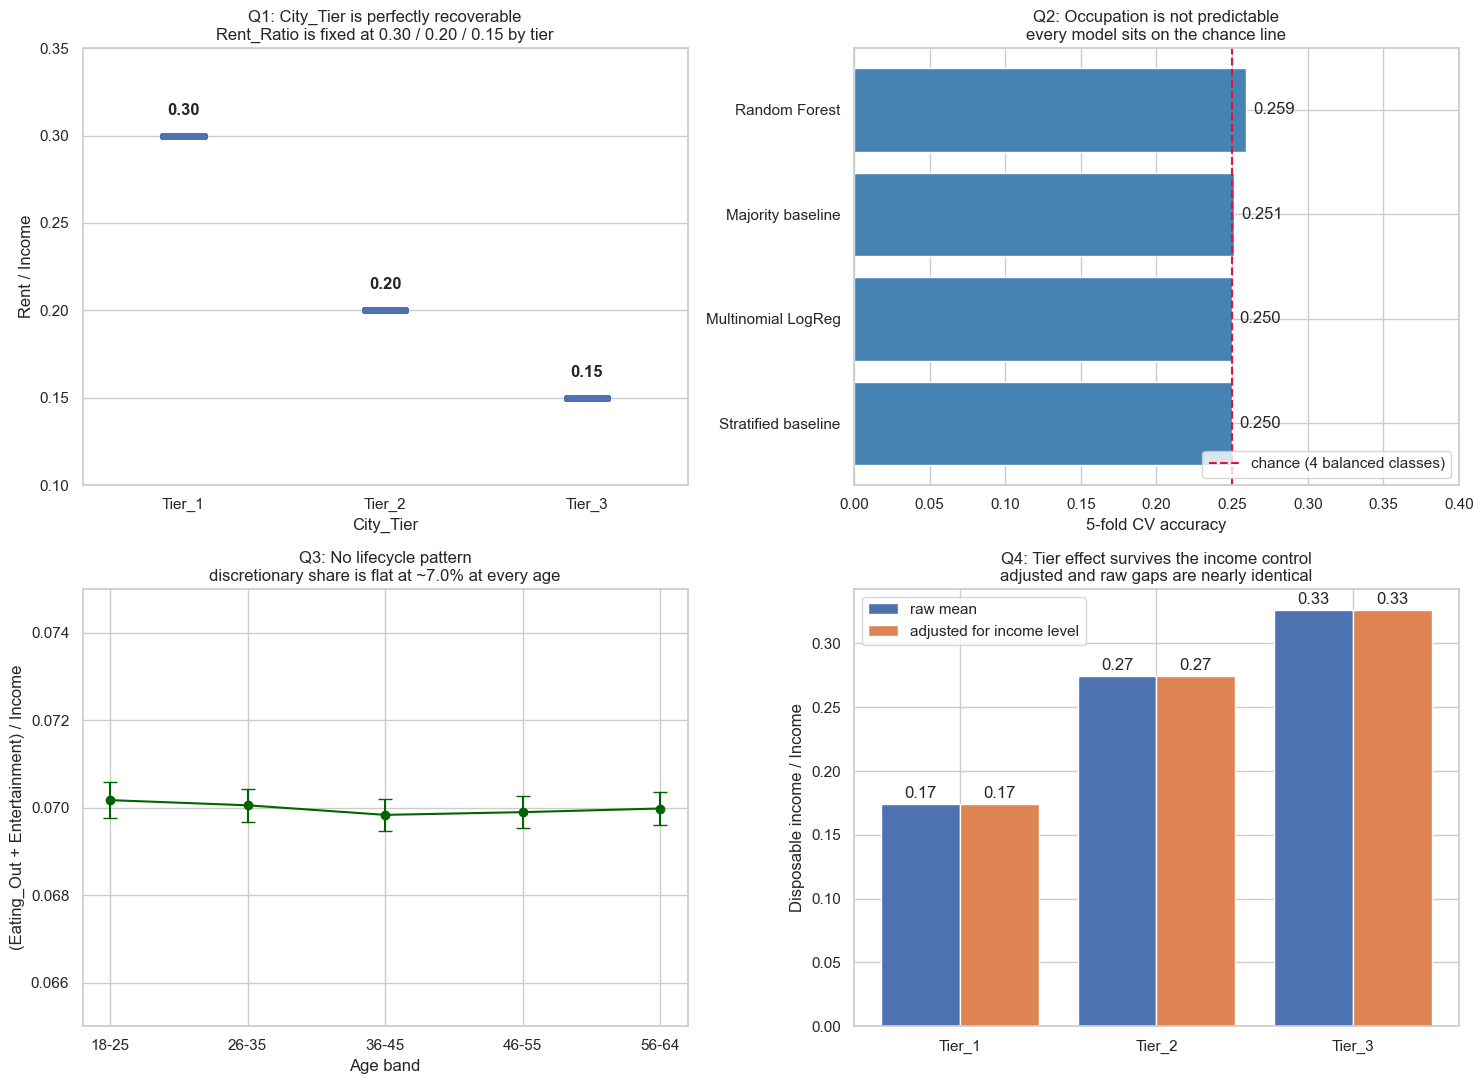

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
tiers = ["Tier_1", "Tier_2", "Tier_3"]

# Q1 - Rent_Ratio is a deterministic tier lookup
ax = axes[0, 0]
sns.stripplot(data=df, x="City_Tier", y="Rent_Ratio", order=tiers, ax=ax)
for tier, val in df.groupby("City_Tier")["Rent_Ratio"].mean().items():
    ax.annotate(f"{val:.2f}", (tiers.index(tier), val + 0.012), ha="center", fontweight="bold")
ax.set_ylim(0.10, 0.35)
ax.set_title("Q1: City_Tier is perfectly recoverable\nRent_Ratio is fixed at 0.30 / 0.20 / 0.15 by tier")
ax.set_ylabel("Rent / Income")

# Q2 - Occupation sits on the chance line
ax = axes[0, 1]
q2_plot = q2_table["CV Accuracy"].sort_values()
ax.barh(q2_plot.index, q2_plot.values, color="steelblue")
ax.axvline(0.25, color="crimson", ls="--", label="chance (4 balanced classes)")
ax.set_xlim(0, 0.4)
for i, v in enumerate(q2_plot.values):
    ax.annotate(f"{v:.3f}", (v + 0.005, i), va="center")
ax.set_title("Q2: Occupation is not predictable\nevery model sits on the chance line")
ax.set_xlabel("5-fold CV accuracy")
ax.legend(loc="lower right")

# Q3 - flat lifecycle profile
ax = axes[1, 0]
band_stats = df.groupby("Age_Band")["Discretionary_Ratio"].agg(["mean", "sem"])
ax.errorbar(
    band_stats.index.astype(str),
    band_stats["mean"],
    yerr=1.96 * band_stats["sem"],
    marker="o",
    capsize=5,
    color="darkgreen",
)
ax.set_ylim(0.065, 0.075)
ax.set_title("Q3: No lifecycle pattern\ndiscretionary share is flat at ~7.0% at every age")
ax.set_ylabel("(Eating_Out + Entertainment) / Income")
ax.set_xlabel("Age band")

# Q4 - tier effect survives the income control
ax = axes[1, 1]
raw = df.groupby("City_Tier")["Disposable_Ratio"].mean().reindex(tiers)
mean_log_income = np.log(df["Income"]).mean()
adj = [
    m_scalefree.params["Intercept"]
    + m_scalefree.params["np.log(Income)"] * mean_log_income
    + m_scalefree.params.get(f"C(City_Tier)[T.{t}]", 0.0)
    for t in tiers
]
x = np.arange(3)
ax.bar(x - 0.2, raw.values, 0.4, label="raw mean")
ax.bar(x + 0.2, adj, 0.4, label="adjusted for income level")
ax.set_xticks(x)
ax.set_xticklabels(tiers)
for i, (r, a) in enumerate(zip(raw.values, adj)):
    ax.annotate(f"{r:.2f}", (i - 0.2, r + 0.005), ha="center")
    ax.annotate(f"{a:.2f}", (i + 0.2, a + 0.005), ha="center")
ax.set_title("Q4: Tier effect survives the income control\nadjusted and raw gaps are nearly identical")
ax.set_ylabel("Disposable income / Income")
ax.legend()

plt.tight_layout()
plt.savefig("../results/bonus_extensions.png", dpi=150, bbox_inches="tight")
plt.show()